In [1]:
from tensorflow.keras.applications import efficientnet
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os


2026-03-22 16:49:50.678571: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774198190.704914    1083 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774198190.712482    1083 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774198190.731486    1083 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774198190.731509    1083 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774198190.731512    1083 computation_placer.cc:177] computation placer alr

In [2]:
train_dir = "/kaggle/input/datasets/testesterone/facial-emotion-recognition/dataset_Train"
test_dir = "/kaggle/input/datasets/testesterone/facial-emotion-recognition/dataset_Test"
img_height = 192
img_width = 192
batch_size = 32

In [14]:
# loading pretrained EfficientNetB0
base_model = EfficientNetB0(
    input_shape=(192, 192, 3),
    include_top=False,
    weights='imagenet'
)

In [15]:
# freezing model
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

In [16]:
# loading train dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb",
    shuffle=True
)

# loading test dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode="rgb"
)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.


In [17]:
# data augmentation

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
])

# performance optimization
autotune = tf.data.AUTOTUNE

# apply augmentation (parallelized)
train_dataset = train_dataset.map(
    lambda x, y: (data_augmentation(x, training=True), y),
    num_parallel_calls=autotune
)

# preprocessing
preprocess_input = efficientnet.preprocess_input

train_dataset = train_dataset.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=autotune
)

test_dataset = test_dataset.map(
    lambda x, y: (preprocess_input(x), y),
    num_parallel_calls=autotune
)

# prefetch 
train_dataset = train_dataset.prefetch(buffer_size=autotune)
test_dataset = test_dataset.prefetch(buffer_size=autotune)

In [18]:
# Defining model
model = tf.keras.models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(7, activation='softmax')
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 6, 6, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,416,426 (16.85 MB)

 Trainable params: 1,860,455 (7.10 MB)

 Non-trainable params: 2,555,971 (9.75 MB)

In [19]:
# compling the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
# fixing overfitting
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)


In [21]:
#LR scheduler
lr_reduce = tf.keras.callbacks.ReduceLROnPlateau(
    mointor = 'val_loss',
    factor = 0.3,
    patience = 2,
    min_lr = 1e-6
)

In [22]:
#saving best model

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model.keras",
    monitor = "val_accuracy",
    save_best_only = True,
    verbose = 1
)

In [23]:
#class weights
labels = np.concatenate([y for x, y in train_dataset], axis = 0)

class_weights = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(labels),
    y = labels
)

class_weights = dict(enumerate(class_weights))

print ("class weights:", class_weights)

class weights: {0: np.float64(1.0266046844269623), 1: np.float64(9.406618610747051), 2: np.float64(1.0010460615781582), 3: np.float64(0.5684387684387684), 4: np.float64(0.8260394187886635), 5: np.float64(0.8491274770777877), 6: np.float64(1.293372978330405)}


Epoch 1/15


I0000 00:00:1774201022.816805    1148 service.cc:152] XLA service 0x7cedd8003310 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774201022.816854    1148 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774201022.816861    1148 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774201026.050522    1148 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-22 17:37:12.638105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:37:12.775584: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:37:13.109176: E external/local_xl

896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.1855 - loss: 2.5645

2026-03-22 17:39:16.791347: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:16.924843: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:17.240749: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:17.382191: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:18.159714: E external/local_xla/xla/stream_

898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - accuracy: 0.1855 - loss: 2.5639

2026-03-22 17:39:44.888236: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:45.022970: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:45.337549: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:45.479647: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-22 17:39:45.621143: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.35330, saving model to best_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 182s 163ms/step - accuracy: 0.1856 - loss: 2.5636 - val_accuracy: 0.3533 - val_loss: 1.7110 - learning_rate: 1.0000e-04
Epoch 2/15
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2340 - loss: 1.9471
Epoch 2: val_accuracy improved from 0.35330 to 0.38883, saving model to best_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 109s 121ms/step - accuracy: 0.2341 - loss: 1.9470 - val_accuracy: 0.3888 - val_loss: 1.6493 - learning_rate: 1.0000e-04
Epoch 3/15
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.2913 - loss: 1.7721
Epoch 3: val_accuracy improved from 0.38883 to 0.43034, saving model to best_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 109s 121ms/step - accuracy: 0.2913 - loss: 1.7721 - val_accuracy: 0.4303 - val_loss: 1.5055 - learning_rate: 1.0000e-04
Epoch 4/15
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.3323 - loss: 1.6931
Epoch 4: val_accuracy im

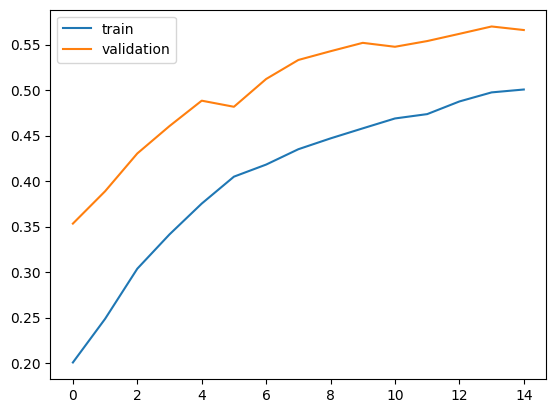

In [24]:
# training the model
history = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15,
    callbacks=[early_stop, lr_reduce, checkpoint],
    class_weight = class_weights
)

# plots
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.legend()
plt.show()


In [20]:
#model = tf.keras.models.load_model("best_model.h5")

In [14]:
#unfreezing full model
#base_model = model.layers[0] 
#base_model.trainable = True

In [15]:
#recompiling with low learning rate
#model.compile(
#    optimizer = tf.keras.optimizers.Adam(5e-6),
#    loss = 'sparse_categorical_crossentropy',
#    metrics = ['accuracy']
#)

In [16]:
# recreate callbacks (was throwing error otherwise)
#early_stop_fine = tf.keras.callbacks.EarlyStopping(
#    monitor='val_loss',
#    patience=3,
#    restore_best_weights=True
#)

#lr_reduce_fine = tf.keras.callbacks.ReduceLROnPlateau(
#    monitor='val_loss',
#    factor=0.3,
#    patience=2,
#    min_lr=1e-6
#)

#checkpoint_fine = tf.keras.callbacks.ModelCheckpoint(
#    "best_model.h5",
#    monitor="val_accuracy",
#    save_best_only=True,
#    verbose=1
#)

Epoch 1/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step - accuracy: 0.5150 - loss: 1.2787
Epoch 1: val_accuracy improved from -inf to 0.56994, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 133s 117ms/step - accuracy: 0.5150 - loss: 1.2787 - val_accuracy: 0.5699 - val_loss: 1.1108 - learning_rate: 1.0000e-05
Epoch 2/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5218 - loss: 1.2584
Epoch 2: val_accuracy improved from 0.56994 to 0.57342, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.5218 - loss: 1.2584 - val_accuracy: 0.5734 - val_loss: 1.1066 - learning_rate: 1.0000e-05
Epoch 3/10
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5304 - loss: 1.2466
Epoch 3: val_accuracy improved from 0.57342 to 0.57425, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.5304 - loss: 1.2466 - val_accuracy: 0.5743 - val_loss: 1.1032 - learning_rate: 1.0000e-05
Epoch 4/10
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5294 - loss: 1.2474
Epoch 4: val_accuracy did not improve from 0.57425
898/898 ━━━━━━━━━━━━━━━━━━━━ 77s 86ms/step - accuracy: 0.5294 - loss: 1.2474 - val_accuracy: 0.5740 - val_loss: 1.1011 - learning_rate: 1.0000e-05
Epoch 5/10
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5289 - loss: 1.2419
Epoch 5: val_accuracy did not improve from 0.57425
898/898 ━━━━━━━━━━━━━━━━━━━━ 77s 86ms/step - accuracy: 0.5289 - loss: 1.2419 - val_accuracy: 0.5743 - val_loss: 1.0967 - learning_rate: 1.0000e-05
Epoch 6/10
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5306 - loss: 1.2368
Epoch 6: val_accuracy improved from 0.57425 to 0.57648, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 86ms/step - accuracy: 0.5307 - loss: 1.2368 - val_accuracy: 0.5765 - val_loss: 1.0936 - learning_rate: 1.0000e-05
Epoch 7/10
896/898 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5343 - loss: 1.2284
Epoch 7: val_accuracy improved from 0.57648 to 0.57885, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.5343 - loss: 1.2284 - val_accuracy: 0.5789 - val_loss: 1.0905 - learning_rate: 1.0000e-05
Epoch 8/10
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.5391 - loss: 1.2180
Epoch 8: val_accuracy did not improve from 0.57885
898/898 ━━━━━━━━━━━━━━━━━━━━ 77s 86ms/step - accuracy: 0.5391 - loss: 1.2180 - val_accuracy: 0.5783 - val_loss: 1.0861 - learning_rate: 1.0000e-05
Epoch 9/10
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.5366 - loss: 1.2228
Epoch 9: val_accuracy did not improve from 0.57885
898/898 ━━━━━━━━━━━━━━━━━━━━ 79s 87ms/step - accuracy: 0.5366 - loss: 1.2228 - val_accuracy: 0.5776 - val_loss: 1.0853 - learning_rate: 1.0000e-05
Epoch 10/10
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5393 - loss: 1.2176
Epoch 10: val_accuracy improved from 0.57885 to 0.58136, saving model to best_model.h5


898/898 ━━━━━━━━━━━━━━━━━━━━ 78s 87ms/step - accuracy: 0.5393 - loss: 1.2176 - val_accuracy: 0.5814 - val_loss: 1.0817 - learning_rate: 1.0000e-05


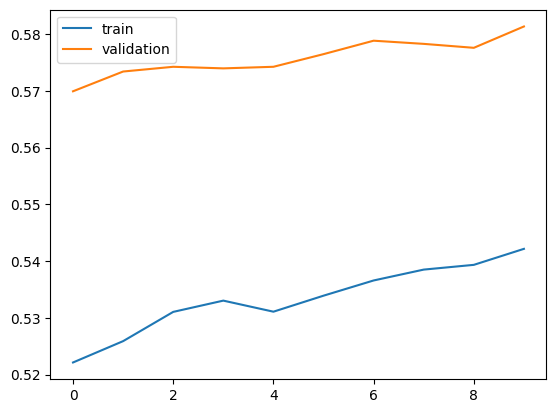

In [17]:
# fine-tuning training
#history_fine = model.fit(
#    train_dataset,
#    validation_data=test_dataset,
#    epochs=15,
#    callbacks=[early_stop_fine, lr_reduce_fine, checkpoint_fine],
#)

#ploting new results
#plt.plot(history_fine.history['accuracy'], label = 'train')
#plt.plot(history_fine.history['val_accuracy'], label = 'validation')
#plt.legend()
#plt.show()

In [25]:
# PHASE 2 — unfreeze full model

base_model.trainable = True

In [26]:
# recompile for fine-tuning

model.compile(
    optimizer=tf.keras.optimizers.Adam(5e-6),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
# fine-tuning training 

history_fine = model.fit(
    train_dataset,
    validation_data=test_dataset,
    epochs=15,
    callbacks=[early_stop, lr_reduce, checkpoint]
)

Epoch 1/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5000 - loss: 1.3310
Epoch 1: val_accuracy improved from 0.56980 to 0.57802, saving model to best_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 160s 147ms/step - accuracy: 0.5000 - loss: 1.3309 - val_accuracy: 0.5780 - val_loss: 1.1247 - learning_rate: 5.0000e-06
Epoch 2/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.5098 - loss: 1.3006
Epoch 2: val_accuracy did not improve from 0.57802
898/898 ━━━━━━━━━━━━━━━━━━━━ 108s 120ms/step - accuracy: 0.5098 - loss: 1.3006 - val_accuracy: 0.5780 - val_loss: 1.1174 - learning_rate: 5.0000e-06
Epoch 3/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accuracy: 0.5179 - loss: 1.2758
Epoch 3: val_accuracy improved from 0.57802 to 0.58080, saving model to best_model.keras
898/898 ━━━━━━━━━━━━━━━━━━━━ 105s 117ms/step - accuracy: 0.5179 - loss: 1.2758 - val_accuracy: 0.5808 - val_loss: 1.1134 - learning_rate: 5.0000e-06
Epoch 4/15
898/898 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step - accu

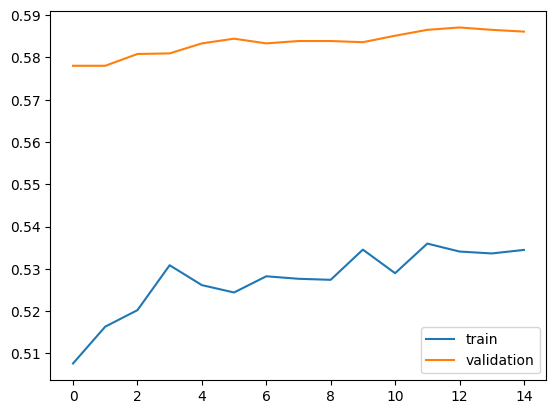

In [28]:
#ploting new results
plt.plot(history_fine.history['accuracy'], label = 'train')
plt.plot(history_fine.history['val_accuracy'], label = 'validation')
plt.legend()
plt.show()

In [29]:
model.save("final_FER_model.keras")

In [32]:
model.save_weights("model.weights.h5")